In [1]:
import pandas as pd
import numpy as np
from datetime import datetime as dt
import re
from urllib.parse import urlparse
from bs4 import BeautifulSoup
import requests
import os
import time
import codecs
from tqdm import tqdm
import matplotlib.pyplot as plt
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

# Data Download

In [2]:
def read_crunchbase():

    companies = pd.read_excel("/Users/jing/Documents/RaShips/web_scraping/WAYBACK/firmlevelall(n=1439).xlsx")       

    return companies

def clean_domain_url(website):
        s =  re.sub(r"www\.","",website)
        s =  re.sub(r"home\.","",s)
        s  = re.sub(r"\:.*","",s)
        s = re.sub(r"http(s?)://(\w+)\.(\w+)\.(\w+)",r"\3.\4",s)
        return s

def split_wayback_url(wayback_url):
    original_url = re.sub(r'http://web.archive.org/web/\d+/',"",wayback_url)
    website_piece = re.sub(r"http(s?)\://","", original_url)

    try:
        (domain, address) = website_piece.split("/", 1)            
    except ValueError:
        domain  = website_piece
        address = ""

    domain = clean_domain_url(domain)
    
    return (domain, address)

def store_page(wayback_url, html, output_folder, crawled_year, year_folder = True):
    (domain, address) = split_wayback_url(wayback_url)

    if year_folder:
        base_directory = "{0}/{1}/{2}".format(output_folder, domain, crawled_year)
    else:
        base_directory = output_folder + "/" + domain

        
    if not os.path.exists(base_directory):
            os.makedirs(base_directory)

    if address == "":
        address = "homepage.html"

    address = address.replace("/","_")
    if len(address) > 255:
        address = address[:255]

    file_path = base_directory +  "/" + address
    outfile = codecs.open(file_path, "w",'utf-8')
    outfile.write(html)
    outfile.close()
    
def clean_downloaded_data(data):
    
    data['timestamp'] = data.apply(lambda x: x['complete_url'].split('/')[4], axis = 1)
    #data['len_timestammp'] = data.apply(lambda x: len(x['timestamp']), axis = 1)
    data['timestamp'] = data.apply(lambda x: re.search(r'/web/(\d{14})/', x['complete_url']).group(1), axis = 1)

    data['download_date'] = data.apply(lambda x: dt.strptime(x['timestamp'][:8], '%Y%m%d'), axis = 1)
    data['download_time'] = data.apply(lambda x: dt.strptime(x['timestamp'][8:], '%H%M%S'), axis = 1)
    data['download_year'] = data.apply(lambda x: x['download_date'].year, axis = 1)

    #data['domain'] = data['url'].apply(split_wayback_url)
    #data['website'] = 'www.' + data['domain'] 

    return data

In [187]:
urls_data = pd.read_excel('List of accelerators_RA.xlsx',
                     sheet_name=0)
urls_data.head()

,accelerator_id,accelerator_name,website
0,a01,10-xcelerator,http://fisher.osu.edu/centers/entrepreneurship...
1,a02,Betaspring,http://betaspring.com
2,a03,Excelerate Labs,http://exceleratelabs.com/
3,a05,HAXLR8R,http://haxlr8r.com
4,a06,i/o ventures,http://ventures.io


In [188]:
firms_data = pd.read_excel('List of accelerators_RA.xlsx',
                     sheet_name=1)
firms_data.head()

,accelerator_id,accelerator_name,seeddb_cohort_id,cohort_name,location,acceleration_date,duration,funding,equity,mentorship,demo_days,verticalist
0,a01,10-xcelerator,a01c01,10-xcelerator 06/01/11,"Columbus, OH US",2011-06-01,NaN,NaN,NaN,NaN,NaN,NaN
1,a01,10-xcelerator,a01c02,10-xcelerator 01/01/12,"Columbus, OH US",2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2,a02,Betaspring,a02c01,Betaspring Summer 2009,"Providence, RI, US",2009-07-01,NaN,NaN,NaN,NaN,NaN,NaN
3,a02,Betaspring,a02c02,Betaspring Summer 2010,"Providence, RI, US",2010-07-01,NaN,NaN,NaN,NaN,NaN,NaN
4,a02,Betaspring,a02c03,Betaspring Summer 2011,"Providence, RI, US",2011-07-01,NaN,NaN,NaN,NaN,NaN,NaN


In [189]:
acc_data = pd.merge(urls_data.loc[:, ['accelerator_id', 'website']], firms_data, on = 'accelerator_id')
acc_data.head()

,accelerator_id,website,accelerator_name,seeddb_cohort_id,cohort_name,location,acceleration_date,duration,funding,equity,mentorship,demo_days,verticalist
0,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c01,10-xcelerator 06/01/11,"Columbus, OH US",2011-06-01,NaN,NaN,NaN,NaN,NaN,NaN
1,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c02,10-xcelerator 01/01/12,"Columbus, OH US",2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2,a02,http://betaspring.com,Betaspring,a02c01,Betaspring Summer 2009,"Providence, RI, US",2009-07-01,NaN,NaN,NaN,NaN,NaN,NaN
3,a02,http://betaspring.com,Betaspring,a02c02,Betaspring Summer 2010,"Providence, RI, US",2010-07-01,NaN,NaN,NaN,NaN,NaN,NaN
4,a02,http://betaspring.com,Betaspring,a02c03,Betaspring Summer 2011,"Providence, RI, US",2011-07-01,NaN,NaN,NaN,NaN,NaN,NaN


In [200]:
def get_wayback_url(website, date):

    date = pd.to_datetime(date)
    timestamp = date.strftime("%Y%m%d")
    wayback_url = "http://archive.org/wayback/available?url={0}&timestamp={1}".format(website, timestamp)

    return wayback_url

In [287]:
def accelerators_data_download(acc_data):
    
    all_websites = acc_data.website.values
    all_dates = acc_data.acceleration_date.values

    valid = []

    for i in tqdm(range(len(all_websites))):

        website = all_websites[i]
        date = pd.to_datetime(all_dates[i])
        timestamp = date.strftime("%Y%m%d")

        wayback_url = "http://archive.org/wayback/available?url={0}&timestamp={1}".format(website, timestamp)

        response = requests.get(wayback_url)
        snapshots = response.json()["archived_snapshots"]

        if len(snapshots) > 0:
            
            url = snapshots['closest']['url']
            clean_url = re.sub("\\?.*", "", url)
            clean_url = re.sub(r"\\#.*", "", clean_url)

            time.sleep(5)

            try: 
                response = requests.get(clean_url)
                html = response.text

                with open('/Users/jing/Documents/RaShips/accelerators/WAYBACK/downloaded_urls_data.txt', 'a') as links_file:
                    links_file.write('url: ' + str(clean_url) + '\n')
                    links_file.write('year: ' + str(date.year) + '\n')
                    links_file.write('website: ' + str(website) + '\n')

                store_page(wayback_url=clean_url,
                            html=html,
                            output_folder="/Users/jing/Documents/RaShips/accelerators/WAYBACK/2025/out",
                            crawled_year = date.year,
                            year_folder=True)
                
                valid.append(1)

            except requests.RequestException as e:
                
                #print(f"Request failed for {clean_url}: {e}")
                valid.append(0)
                continue

            except Exception as e:
                #print(f"Failed to store or process {clean_url}: {e}")
                valid.append(0)
                continue
            
        else:
            valid.append(0)
            continue

    return valid

In [ ]:
i = 0

valid = accelerators_data_download(data = acc_data)
acc_data['valid_0'] = valid

missing_acc = acc_data.loc[acc_data.valid_0 == 0, :]
missing_acc.to_excel(f'accelerators_data_{i}.xlsx', index = False)

no_change_iteration = 0
missing_num = []

while missing_acc.shape[0] > 0 and no_change_iteration < 5:

    missing_num.append(missing_acc.shape[0])
    
    if len(missing_num) > 1:
        if missing_num[-1] == missing_num[-2]:
            no_change_iteration += 1
        else:
            no_change_iteration = 0
 
    valid = accelerators_data_download(acc_data=missing_acc)
    missing_acc['valid_0'] = valid
    missing_acc.to_excel(f'accelerators_data_{i}.xlsx', index = False)
    missing_acc = missing_acc.loc[missing_acc.valid_0 == 0,:].reset_index(drop = True)

    i += 1

100%|██████████| 216/216 [27:40<00:00,  7.69s/it]
/var/folders/77/3w18kg3x0d18_zdpyxkjgqdc0000gn/T/ipykernel_95531/2076780715.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_acc['valid_0'] = valid
100%|██████████| 15/15 [00:06<00:00,  2.49it/s]


In [221]:
all_files = os.listdir()

downloaded_data = pd.DataFrame()

for file in all_files:
    if 'accelerators_data' in file:
        single_data = pd.read_excel(file)
        downloaded_data = pd.concat([downloaded_data, single_data.loc[single_data.valid_0 == 1, :]])

downloaded_data.drop_duplicates(inplace=True)
print(downloaded_data.shape)
downloaded_data.head()

(388, 14)


,accelerator_id,website,accelerator_name,seeddb_cohort_id,cohort_name,location,acceleration_date,duration,funding,equity,mentorship,demo_days,verticalist,valid_0
0,a11,http://ycombinator.com/,Y Combinator,a11c01,YC S05,"Boston, MA, US",2005-06-01,NaN,NaN,NaN,NaN,NaN,NaN,1
1,a11,http://ycombinator.com/,Y Combinator,a11c02,YC W06,"Mountain View, CA, US",2006-01-01,NaN,NaN,NaN,NaN,NaN,NaN,1
3,a11,http://ycombinator.com/,Y Combinator,a11c17,YC S13,"Mountain View, CA, US",2013-06-01,NaN,NaN,NaN,NaN,NaN,NaN,1
6,a12,http://500.co,500startups,a12c02,500startups Batch 2,"Mountain View, CA, US",2011-06-01,NaN,NaN,NaN,NaN,NaN,NaN,1
8,a12,http://500.co,500startups,a12c04,500startups Batch 4,"Mountain View, CA, US",2012-05-01,NaN,NaN,NaN,NaN,NaN,NaN,1


In [211]:
missing_data = acc_data.loc[~acc_data.seeddb_cohort_id.isin(downloaded_data.seeddb_cohort_id), :].reset_index(drop = True)
print(missing_data.shape)
missing_data.head()

(15, 14)


,accelerator_id,website,accelerator_name,seeddb_cohort_id,cohort_name,location,acceleration_date,duration,funding,equity,mentorship,demo_days,verticalist,url
0,a12,http://500.co,500startups,a12c01,500startups Batch 1,"Mountain View, CA, US",2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...
1,a12,http://500.co,500startups,a12c03,500startups Batch 3,"Mountain View, CA, US",2011-11-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...
2,a12,http://500.co,500startups,a12c08,500startups Batch 8,"San Francisco, CA, US",2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...
3,a129,http://k5launch.com/,K5Launch,a129c01,K5Launch 02/01/12,"Los Angeles, CA US",2012-02-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...
4,a14,http://blueprinthealth.org,Blueprint Health,a14c01,Blueprint Health 2012 Winter,"New York, NY, US",2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...


In [ ]:
#missing_data.to_excel('missing_accelerators.xlsx',
                      #index=False)

In [222]:
outputs_folder = '/Users/jing/Documents/RaShips/accelerators/WAYBACK/'

downloaded_urls = []
downloaded_years = []
downloaded_webites = []

downloaded_dict = {'url':[],
                   'year':[],
                   'website':[]}

with open(outputs_folder + 'downloaded_urls_data.txt') as file:
    for line in file.readlines():
        argument = line.split(':')[0]
        downloaded_dict[argument].append(line[len(argument)+2:-1])

downloaded_urls_data = pd.DataFrame(downloaded_dict)
downloaded_urls_data.drop_duplicates(inplace=True)
print(downloaded_urls_data.shape)
downloaded_urls_data.head()

(344, 3)


,url,year,website
0,http://archive.org/wayback/available?url=http:...,2011,http://fisher.osu.edu/centers/entrepreneurship...
1,http://archive.org/wayback/available?url=http:...,2010,http://exceleratelabs.com/
2,http://archive.org/wayback/available?url=http:...,2011,http://exceleratelabs.com/
3,http://archive.org/wayback/available?url=http:...,2012,http://haxlr8r.com
4,http://archive.org/wayback/available?url=http:...,2014,http://haxlr8r.com


In [225]:
acc_data['url'] = acc_data.apply(lambda x: get_wayback_url(x['website'], x['acceleration_date']), axis = 1)
acc_data.drop_duplicates('url', 
                         inplace=True)
print(acc_data.shape)
acc_data.head()

(356, 14)


,accelerator_id,website,accelerator_name,seeddb_cohort_id,cohort_name,location,acceleration_date,duration,funding,equity,mentorship,demo_days,verticalist,url
0,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c01,10-xcelerator 06/01/11,"Columbus, OH US",2011-06-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...
1,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c02,10-xcelerator 01/01/12,"Columbus, OH US",2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...
2,a02,http://betaspring.com,Betaspring,a02c01,Betaspring Summer 2009,"Providence, RI, US",2009-07-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...
3,a02,http://betaspring.com,Betaspring,a02c02,Betaspring Summer 2010,"Providence, RI, US",2010-07-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...
4,a02,http://betaspring.com,Betaspring,a02c03,Betaspring Summer 2011,"Providence, RI, US",2011-07-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...


In [256]:
complete_data = pd.merge(acc_data, downloaded_urls_data.loc[:, ['url', 'year']], on = 'url')
#complete_data = clean_downloaded_data(complete_data)
complete_data.head()

,accelerator_id,website,accelerator_name,seeddb_cohort_id,cohort_name,location,acceleration_date,duration,funding,equity,mentorship,demo_days,verticalist,url,year
0,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c01,10-xcelerator 06/01/11,"Columbus, OH US",2011-06-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...,2011
1,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c02,10-xcelerator 01/01/12,"Columbus, OH US",2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...,2012
2,a02,http://betaspring.com,Betaspring,a02c01,Betaspring Summer 2009,"Providence, RI, US",2009-07-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...,2009
3,a02,http://betaspring.com,Betaspring,a02c02,Betaspring Summer 2010,"Providence, RI, US",2010-07-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...,2010
4,a02,http://betaspring.com,Betaspring,a02c03,Betaspring Summer 2011,"Providence, RI, US",2011-07-01,NaN,NaN,NaN,NaN,NaN,NaN,http://archive.org/wayback/available?url=http:...,2011


In [258]:
wayback_urls = complete_data.url.values
clean_urls = []

for wayback_url in tqdm(wayback_urls):

    response = requests.get(wayback_url)
    snapshots = response.json()["archived_snapshots"]

    if len(snapshots) > 0:
        
        url = snapshots['closest']['url']
        clean_url = re.sub("\\?.*", "", url)
        clean_url = re.sub(r"\\#.*", "", clean_url)
        clean_urls.append(clean_url)

    else:

        clean_urls.append(None)

100%|██████████| 344/344 [19:29<00:00,  3.40s/it]


In [279]:
complete_data.loc[complete_data.complete_url.isnull(), 'complete_url'] = clean_urls

In [ ]:
complete_data = clean_downloaded_data(complete_data)
complete_data['snap_distance'] = complete_data.apply(lambda x: (max(x['acceleration_date'], x['download_date']) - min(x['acceleration_date'], x['download_date'])).days, axis = 1)
#complete_data.to_excel('accelerators_complete_data.xlsx', index = False)
complete_data.head()

,accelerator_id,website,accelerator_name,seeddb_cohort_id,cohort_name,location,acceleration_date,duration,funding,equity,...,demo_days,verticalist,url,year,complete_url,timestamp,download_date,download_time,download_year,snap_distance
0,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c01,10-xcelerator 06/01/11,"Columbus, OH US",2011-06-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2011,http://web.archive.org/web/20110613102235/http...,20110613102235,2011-06-13,1900-01-01 10:22:35,2011,12
1,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c02,10-xcelerator 01/01/12,"Columbus, OH US",2012-01-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2012,http://web.archive.org/web/20120107013515/http...,20120107013515,2012-01-07,1900-01-01 01:35:15,2012,6
2,a02,http://betaspring.com,Betaspring,a02c01,Betaspring Summer 2009,"Providence, RI, US",2009-07-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2009,http://web.archive.org/web/20101224050550/http...,20101224050550,2010-12-24,1900-01-01 05:05:50,2010,541
3,a02,http://betaspring.com,Betaspring,a02c02,Betaspring Summer 2010,"Providence, RI, US",2010-07-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2010,http://web.archive.org/web/20101224050550/http...,20101224050550,2010-12-24,1900-01-01 05:05:50,2010,176
4,a02,http://betaspring.com,Betaspring,a02c03,Betaspring Summer 2011,"Providence, RI, US",2011-07-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2011,http://web.archive.org/web/20110707230422/http...,20110707230422,2011-07-07,1900-01-01 23:04:22,2011,6


In [ ]:
#acc_data.loc[acc_data.url.duplicated(), :].reset_index(drop = True).to_excel('duplicated_accelerators.xlsx', index = False)

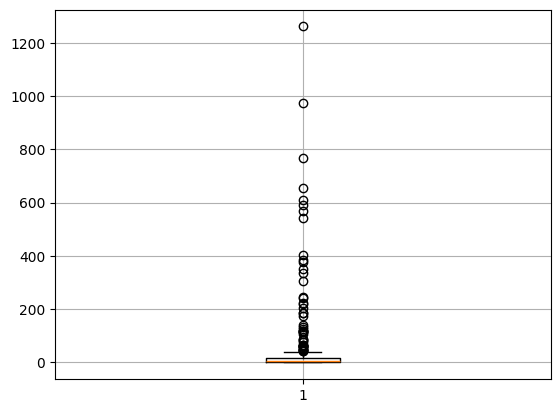

In [296]:
complete_data = pd.read_excel('accelerators_complete_data.xlsx')
plt.boxplot(complete_data.snap_distance)
plt.grid()
plt.show()

In [304]:
thresholds = np.arange(50, 400, 50)

for threshold in thresholds:
    print(f'Snap distance greater than {threshold}: {(complete_data.snap_distance.values >= threshold).sum()}')

Snap distance greater than 50: 43
Snap distance greater than 100: 31
Snap distance greater than 150: 22
Snap distance greater than 200: 19
Snap distance greater than 250: 14
Snap distance greater than 300: 14
Snap distance greater than 350: 11


In [306]:
backward = (complete_data.download_date.values <= complete_data.acceleration_date.values)
backward.mean()

np.float64(0.49709302325581395)

In [310]:
threshold = 50
sub_complete = complete_data.loc[complete_data.snap_distance <= threshold, :]
backward = (sub_complete.download_date.values <= sub_complete.acceleration_date.values)
backward.mean()

np.float64(0.5049833887043189)

# Selenium Download

In [3]:
outputs_folder = "/Users/jing/Documents/RaShips/accelerators/WAYBACK/2025/out"

all_firms = os.listdir(outputs_folder)
files_dict = {}

for firm in all_firms:

    if '.DS_Store' not in firm:

        files_dict[firm] = {}
        all_years = os.listdir(outputs_folder + '/' + firm)

        for year in all_years:

            if '.DS_Store' not in year:

                files_dict[firm][year] = []
                all_files = os.listdir(outputs_folder + '/' + firm + '/' + year)

                for file in all_files:

                    if '.DS_Store' not in file:

                        files_dict[firm][year].append(outputs_folder + '/' + firm + '/' + year + '/' + file)

In [ ]:
i = 8
trial_file = files_dict[all_firms[i]]['2015'][0]
print(trial_file)

with open(trial_file, "r", encoding="utf-8") as file:
    html_content = file.read()
    soup = BeautifulSoup(html_content, "html.parser")

all_text = soup.get_text()
print(html_content)

/Users/jing/Documents/RaShips/accelerators/WAYBACK/2025/out/seedsumo.com/2015/homepage.html
<!doctype html>

<html xmlns:og="http://opengraphprotocol.org/schema/" xmlns:fb="http://www.facebook.com/2008/fbml" xmlns:website="http://ogp.me/ns/website" lang="en-US" class="squarespace-damask" itemscope itemtype="http://schema.org/WebPage">
  <head><script type="text/javascript" src="https://web-static.archive.org/_static/js/bundle-playback.js?v=1B2M2Y8A" charset="utf-8"></script>
<script type="text/javascript" src="https://web-static.archive.org/_static/js/wombat.js?v=1B2M2Y8A" charset="utf-8"></script>
<script>window.RufflePlayer=window.RufflePlayer||{};window.RufflePlayer.config={"autoplay":"on","unmuteOverlay":"hidden"};</script>
<script type="text/javascript" src="https://web-static.archive.org/_static/js/ruffle/ruffle.js"></script>
<script type="text/javascript">
    __wm.init("http://web.archive.org/web");
  __wm.wombat("http://www.seedsumo.com/","20150425030442","http://web.archive.o

In [7]:
print(all_text)

















Seed Sumo










































Apply Now


Hot Pepper Pitch


Perks


Program


Mentors


Portfolio


Sumo Blog






















Apply Now


Hot Pepper Pitch


Perks


Program


Mentors


Portfolio


Sumo Blog











SUMOSIZE YOUR STARTUP
Slide 2
Workspace
Slide 4



























SUMOSIZE YOUR STARTUP
 
100-day Boot Camp for Startups |  Seed Fund

SCROLL DOWN





SUMOSIZE YOUR STARTUP
 
100-day Boot Camp for Startups |  Seed Fund










Capital50k to 400kWe offer 50k for a small % in the accelerator and up to 400k is available from Sumo Fund if certain milestones are met.  We aim to be a true capital partner for your startup.







Mentorsover 100 coachesAccess to strategists, consultants, and business owners that have started and scaled businesses. Over 800 years of combined experience in the network. Not to mention the 4,000 virtual advisors available.







Customerstap into our networksWe help get you to MVP, then scour

In [8]:
complete_data = pd.read_excel('accelerators_complete_data.xlsx')
complete_data.head()

,accelerator_id,website,accelerator_name,seeddb_cohort_id,cohort_name,location,acceleration_date,duration,funding,equity,...,demo_days,verticalist,url,year,complete_url,timestamp,download_date,download_time,download_year,snap_distance
0,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c01,10-xcelerator 06/01/11,"Columbus, OH US",2011-06-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2011,http://web.archive.org/web/20110613102235/http...,20110613102235,2011-06-13,1900-01-01 10:22:35,2011,12
1,a01,http://fisher.osu.edu/centers/entrepreneurship...,10-xcelerator,a01c02,10-xcelerator 01/01/12,"Columbus, OH US",2012-01-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2012,http://web.archive.org/web/20120107013515/http...,20120107013515,2012-01-07,1900-01-01 01:35:15,2012,6
2,a02,http://betaspring.com,Betaspring,a02c01,Betaspring Summer 2009,"Providence, RI, US",2009-07-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2009,http://web.archive.org/web/20101224050550/http...,20101224050550,2010-12-24,1900-01-01 05:05:50,2010,541
3,a02,http://betaspring.com,Betaspring,a02c02,Betaspring Summer 2010,"Providence, RI, US",2010-07-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2010,http://web.archive.org/web/20101224050550/http...,20101224050550,2010-12-24,1900-01-01 05:05:50,2010,176
4,a02,http://betaspring.com,Betaspring,a02c03,Betaspring Summer 2011,"Providence, RI, US",2011-07-01,NaN,NaN,NaN,...,NaN,NaN,http://archive.org/wayback/available?url=http:...,2011,http://web.archive.org/web/20110707230422/http...,20110707230422,2011-07-07,1900-01-01 23:04:22,2011,6


In [8]:
trial_url = complete_data.complete_url.values[0]

# Use headless Chrome
options = Options()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--no-sandbox")

# Initialize WebDriver
driver = webdriver.Chrome(options=options)

driver.get(trial_url)

time.sleep(3)

html = driver.page_source

soup = BeautifulSoup(html, "html.parser")
text = soup.get_text(separator="\n", strip=True)

print(text)

Fisher College of Business | 10-xelerator  | New Venture Accelerator
The Wayback Machine - http://fisher.osu.edu:80/centers/entrepreneurship/10x/
The Ohio State University
Help
BuckeyeLink
Map & Directions
Find People
BuckeyeMail
Search Ohio State
Offices & Departments
:
MyFisher
:
Social Media
:
Newsroom
:
Giving
:
Webmail
Academics
Admissions
Advising
Events and Competitions
Future Students
Scholarships
Study Abroad
Full Time MBA
MBA for Working Professionals
Executive MBA
Master of Accounting
Master of Labor and Human Resources
Master in Business Logistics Engineering
Master of Business Operational Excellence
Specialized Masters - Finance
Dual Degrees
Information Sessions
Accounting / MIS
Labor / HR
Business Administration
Open Enrollment Programs
Custom Programs
Online Courses
Executive Updates
Home
/
Centers
/
Entrepreneurship
/
10x
Entrepreneurship
Students
OSU Business Plan Competition
Event Calendar
Press Releases
Resources
About The Center
Thomas L. Wheeler Internship Program


In [9]:
def accelerators_data_download_selenium(acc_data):

    all_dates = acc_data.acceleration_date.values
    all_complete_urls = acc_data.complete_url.values

    options = Options()
    options.add_argument("--headless")
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")

    valid = []
    error_counter = 0

    for i in tqdm(range(len(all_complete_urls))):

        year = pd.to_datetime(all_dates[i]).year
        complete_url = all_complete_urls[i]

        domain, address = split_wayback_url(complete_url)

        if not os.path.isfile(f'/Users/jing/Documents/RaShips/accelerators/WAYBACK/2025/out/{domain}/{year}/homepage.txt'):

            try:

                driver = webdriver.Chrome(options=options)
                driver.get(complete_url)
                
                time.sleep(3)

                html = driver.page_source

                soup = BeautifulSoup(html, "html.parser")
                text = soup.get_text(separator="\n", strip=True)

                with open(f'/Users/jing/Documents/RaShips/accelerators/WAYBACK/2025/out/{domain}/{year}/homepage.txt', 'w') as file:
                    file.write(text)
                    file.close()

                valid.append(1)

            except:
                error_counter += 1
                #print(f'Failed Download, Total Errors: {error_counter}')
                valid.append(0)

        else:

            valid.append(1)

    return valid, error_counter

In [10]:
valid = np.array([0])
no_change_iteration = 0
no_valid_nums = []

while not (valid == 1).all() and no_change_iteration < 10:

    if len(no_valid_nums) > 1:

        if no_valid_nums[-1] == no_valid_nums[-2]:
            no_change_iteration += 1
        else:
            no_change_iteration = 0

    valid, error_counter = accelerators_data_download_selenium(acc_data=complete_data)
    print(f'Number of errors: {error_counter}')
    valid = np.array(valid)

  0%|          | 0/344 [00:00<?, ?it/s]

100%|██████████| 344/344 [31:31<00:00,  5.50s/it]


Number of errors: 16


100%|██████████| 344/344 [02:45<00:00,  2.08it/s]


Number of errors: 4


100%|██████████| 344/344 [00:31<00:00, 10.78it/s]


Number of errors: 2


100%|██████████| 344/344 [00:00<00:00, 30319.42it/s]

Number of errors: 0


In [24]:
valid = [1,1]

valid = np.array(valid)
if (valid == 1).all() == True:
    print('good')

good


# Single Website Attempt

In [146]:
i = 0
website = acc_data.website.values[i]
date = pd.to_datetime(acc_data.acceleration_date.values[i])
timestamp = date.strftime("%Y%m%d")

In [147]:
#print("\t .Getting snapshots.  Timestamp = {0}".format(timestamp))
wayback_url = "https://archive.org/wayback/available?url={0}&timestamp={1}".format(website, timestamp)

response = requests.get(wayback_url)
snapshots = response.json()["archived_snapshots"]
snapshots

{'closest': {'status': '200',
  'available': True,
  'url': 'http://web.archive.org/web/20110613102235/http://fisher.osu.edu:80/centers/entrepreneurship/10x/',
  'timestamp': '20110613102235'}}

In [148]:
url = snapshots['closest']['url']

In [149]:
clean_url = re.sub("\\?.*", "", url)
clean_url = re.sub(r"\\#.*", "", clean_url)
clean_url

'http://web.archive.org/web/20110613102235/http://fisher.osu.edu:80/centers/entrepreneurship/10x/'

In [150]:
time.sleep(5)
response = requests.get(clean_url)
html = response.text
html

'<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">\n<html xmlns="http://www.w3.org/1999/xhtml">\n<head><script type="text/javascript" src="https://web-static.archive.org/_static/js/bundle-playback.js?v=1B2M2Y8A" charset="utf-8"></script>\n<script type="text/javascript" src="https://web-static.archive.org/_static/js/wombat.js?v=1B2M2Y8A" charset="utf-8"></script>\n<script>window.RufflePlayer=window.RufflePlayer||{};window.RufflePlayer.config={"autoplay":"on","unmuteOverlay":"hidden"};</script>\n<script type="text/javascript" src="https://web-static.archive.org/_static/js/ruffle/ruffle.js"></script>\n<script type="text/javascript">\n    __wm.init("http://web.archive.org/web");\n  __wm.wombat("http://fisher.osu.edu:80/centers/entrepreneurship/10x/","20110613102235","http://web.archive.org/","web","https://web-static.archive.org/_static/",\n\t      "1307960555");\n</script>\n<link rel="stylesheet" type="text/css" href=

In [151]:
output_folder="/Users/jing/Documents/RaShips/accelerators/WAYBACK/2025/out",
crawled_year = date.year,
year_folder=True

(domain, address) = split_wayback_url(wayback_url)

if year_folder:
    base_directory = "{0}/{1}/{2}".format(output_folder, domain, crawled_year)
else:
    base_directory = output_folder + "/" + domain

    
if not os.path.exists(base_directory):
        os.makedirs(base_directory)

if address == "":
    address = "homepage.html"

address = address.replace("/","_")
if len(address) > 255:
    address = address[:255]

In [153]:
wayback_url

'https://archive.org/wayback/available?url=http://fisher.osu.edu/centers/entrepreneurship/10x/&timestamp=20110601'

In [154]:
store_page(wayback_url=clean_url,
           html=html,
           output_folder="/Users/jing/Documents/RaShips/accelerators/WAYBACK/2025/out",
           crawled_year = date.year,
           year_folder=True)